<a href="https://colab.research.google.com/github/Harshavardhan88/ELEVATELAB_TASK-6/blob/main/task_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1: Import Required Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap


# 2: Load and Clean the Dataset

In [12]:
df = pd.read_csv('Iris.csv')
df.drop('Id', axis=1, inplace=True)
print("Null values:\n", df.isnull().sum())
df.dropna(inplace=True)
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.head())

Null values:
 SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Duplicate rows: 3
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa


# 3: Split Features and Target, Then Normalize Features

In [13]:
X = df.drop('Species', axis=1)
y = df['Species']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 4: Train/Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


# 5: Train KNN with Different Values of K and Find Best One

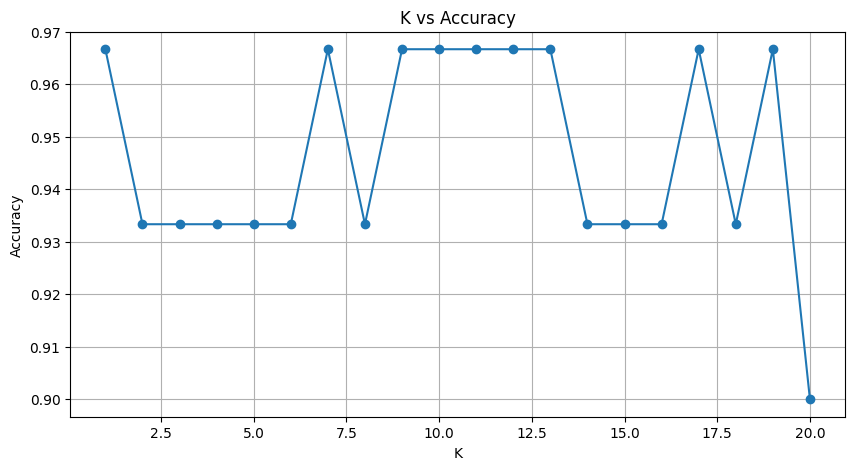

Best K value: 1


In [15]:
accuracies = []
k_values = range(1, 21)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)


plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o')
plt.title('K vs Accuracy')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f'Best K value: {best_k}')


# 6: Final KNN Model with Best K & Evaluation

Final Accuracy: 0.9666666666666667


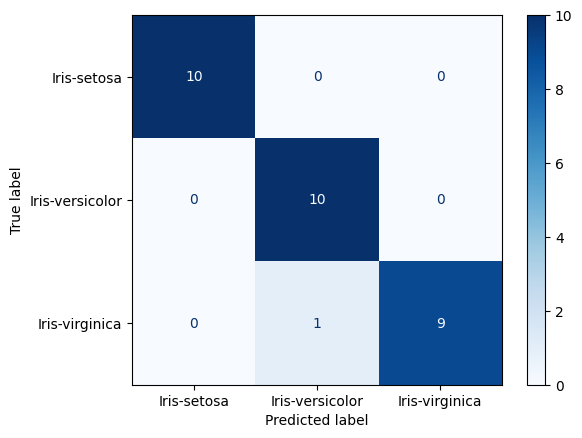

In [16]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)

y_pred_final = knn_final.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final, labels=knn_final.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_final.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()


# 7: Visualize Decision Boundary Using PCA (2D)

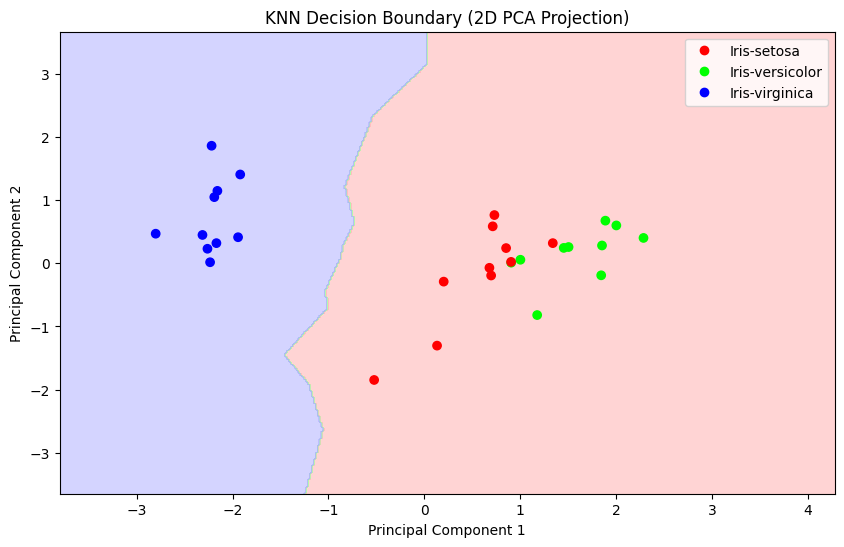

In [17]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_reduced, y, test_size=0.2, random_state=42, stratify=y)

knn_2d = KNeighborsClassifier(n_neighbors=best_k)
knn_2d.fit(X_train_2d, y_train_2d)

h = 0.02
x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z_probs = knn_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])

Z = Z_probs[:, 0].reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']), alpha=0.5)
scatter = plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                      c=pd.factorize(y_test_2d)[0],
                      cmap=ListedColormap(['#FF0000', '#00FF00', '#0000FF']))
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('KNN Decision Boundary (2D PCA Projection)')

plt.legend(handles=scatter.legend_elements()[0],
           labels=[str(label) for label in knn_2d.classes_])

plt.show()
